# Sentiment Model Training — FUZZ CHANNEL Comments

**Project 2 | High Performance Data Processing (SECP3133) — Member 2**

---

### What this notebook does
| Step | Input | Output |
|---|---|---|
| Load | `cleaned_data.csv` | DataFrame |
| Split | full data | 70% train / 20% test / 10% val (stratified) |
| Model A | `tokens` + TF-IDF | Logistic Regression → `models/logreg_tfidf.joblib` |
| Model B | `clean_text` | DistilBERT (multilingual) → `models/distilbert_sentiment/` |
| Compare | val/test metrics | `models/best_model_info.json` |
| Benchmark | full dataset | batch inference timing (records/sec) for Week 4 batch-vs-stream |

**Why these two models:** Logistic Regression on TF-IDF is the classical-ML baseline — fast, interpretable, easy to serialize for Spark. DistilBERT-multilingual handles the Malay/English code-switching natively and should be the stronger model.

**Labels:** `negative` · `neutral` · `positive` (pseudo-labels from `cardiffnlp/twitter-xlm-roberta-base-sentiment`)

## 1. Setup & Imports

Install if missing:
```bash
pip install pandas scikit-learn joblib transformers torch datasets evaluate matplotlib seaborn
```

In [1]:
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Torch device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)
print(f'Models dir   : {MODELS_DIR.resolve()}')

Torch device : cuda
GPU          : NVIDIA GeForce GTX 1050 Ti
Models dir   : C:\Users\user\Documents\hpdp_project_2\models


In [2]:
DATA_PATH = Path('data') / 'cleaned_data.csv'

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns')

# Drop rows with missing inputs/labels
df = df.dropna(subset=['clean_text', 'tokens', 'sentiment_label']).copy()
df = df[df['tokens'].str.strip() != ''].copy()
df = df[df['clean_text'].str.strip() != ''].copy()
df = df.reset_index(drop=True)
print(f'Usable  : {df.shape[0]:,} rows')

print('\nLabel distribution:')
print(df['sentiment_label'].value_counts())
print(f'\nMajority/Minority ratio: '
      f"{df['sentiment_label'].value_counts().max() / df['sentiment_label'].value_counts().min():.2f}x")

Loaded  : 11,999 rows × 13 columns
Usable  : 11,836 rows

Label distribution:
sentiment_label
neutral     5028
negative    3662
positive    3146
Name: count, dtype: int64

Majority/Minority ratio: 1.60x


## 2. Train / Test / Validation Split — 70 / 20 / 10 (stratified)

Two-step split (sklearn doesn't do three-way natively):
1. Hold out 10% for validation.
2. From the remaining 90%, split into train (70/90 ≈ 0.778) and test (20/90 ≈ 0.222).

Stratified on `sentiment_label` so class proportions are preserved in every split.

In [3]:
SEED = 42

# Step 1: hold out 10% validation
df_rest, df_val = train_test_split(
    df, test_size=0.10, stratify=df['sentiment_label'], random_state=SEED,
)

# Step 2: split the remaining 90% into 70% train / 20% test
df_train, df_test = train_test_split(
    df_rest, test_size=(20/90), stratify=df_rest['sentiment_label'], random_state=SEED,
)

for name, part in [('train', df_train), ('test', df_test), ('val', df_val)]:
    pct = 100 * len(part) / len(df)
    print(f'{name:<6} : {len(part):>5,} rows ({pct:.1f}%)')
    print(f'         {dict(part["sentiment_label"].value_counts())}')

train  : 8,284 rows (70.0%)
         {'neutral': np.int64(3519), 'negative': np.int64(2563), 'positive': np.int64(2202)}
test   : 2,368 rows (20.0%)
         {'neutral': np.int64(1006), 'negative': np.int64(733), 'positive': np.int64(629)}
val    : 1,184 rows (10.0%)
         {'neutral': np.int64(503), 'negative': np.int64(366), 'positive': np.int64(315)}


## 3. Evaluation helper

Reports accuracy, precision (macro), recall (macro), F1 (macro), plus a confusion matrix plot.

In [4]:
LABELS = ['negative', 'neutral', 'positive']

def evaluate(y_true, y_pred, model_name, split_name='test'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'\n=== {model_name} — {split_name} ===')
    print(f'Accuracy        : {acc:.4f}')
    print(f'Precision (mac) : {prec:.4f}')
    print(f'Recall    (mac) : {rec:.4f}')
    print(f'F1        (mac) : {f1:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — {split_name} (confusion matrix)')
    plt.tight_layout(); plt.show()

    return {'accuracy': acc, 'precision_macro': prec,
            'recall_macro': rec, 'f1_macro': f1}

## 4. Model A — Logistic Regression on TF-IDF

Pipeline: `tokens` → `TfidfVectorizer(ngram_range=(1,2))` → `LogisticRegression(class_weight='balanced')`.

Class weighting compensates for the mild imbalance (neutral is over-represented at 42.8%).
Saved as a single sklearn `Pipeline` so Member 3 can `joblib.load(...).predict([text])` from Spark.

In [5]:
logreg_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=50000,
        sublinear_tf=True,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED,
    )),
])

t0 = time.time()
logreg_pipe.fit(df_train['tokens'], df_train['sentiment_label'])
print(f'LogReg trained in {time.time() - t0:.1f}s')
print(f'Vocab size: {len(logreg_pipe.named_steps["tfidf"].vocabulary_):,}')

LogReg trained in 1.0s
Vocab size: 11,096



=== Logistic Regression — val ===
Accuracy        : 0.6419
Precision (mac) : 0.6382
Recall    (mac) : 0.6427
F1        (mac) : 0.6399

Classification report:
              precision    recall  f1-score   support

    negative       0.62      0.67      0.65       366
     neutral       0.67      0.63      0.65       503
    positive       0.62      0.63      0.62       315

    accuracy                           0.64      1184
   macro avg       0.64      0.64      0.64      1184
weighted avg       0.64      0.64      0.64      1184



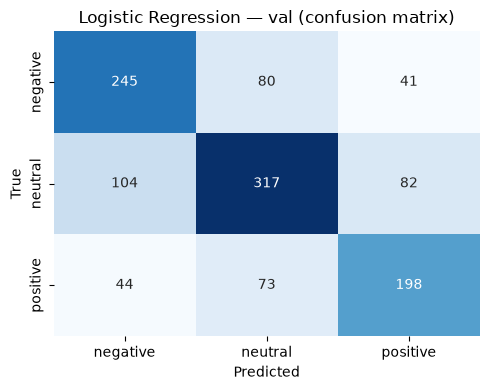


=== Logistic Regression — test ===
Accuracy        : 0.6136
Precision (mac) : 0.6109
Recall    (mac) : 0.6119
F1        (mac) : 0.6112

Classification report:
              precision    recall  f1-score   support

    negative       0.58      0.61      0.59       733
     neutral       0.64      0.62      0.63      1006
    positive       0.61      0.60      0.61       629

    accuracy                           0.61      2368
   macro avg       0.61      0.61      0.61      2368
weighted avg       0.61      0.61      0.61      2368



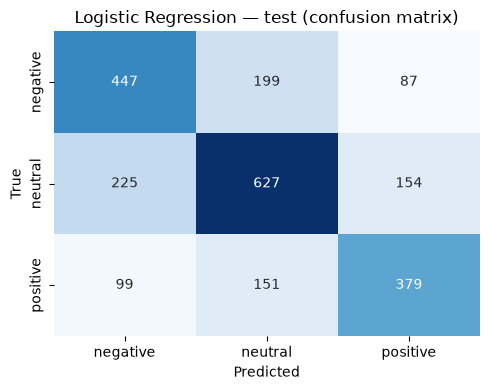


Saved → C:\Users\user\Documents\hpdp_project_2\models\logreg_tfidf.joblib (671.8 KB)


In [6]:
# Evaluate on validation, then test
logreg_val_pred  = logreg_pipe.predict(df_val['tokens'])
logreg_val_m     = evaluate(df_val['sentiment_label'], logreg_val_pred,
                            'Logistic Regression', 'val')

logreg_test_pred = logreg_pipe.predict(df_test['tokens'])
logreg_test_m    = evaluate(df_test['sentiment_label'], logreg_test_pred,
                            'Logistic Regression', 'test')

# Save
LOGREG_PATH = MODELS_DIR / 'logreg_tfidf.joblib'
joblib.dump(logreg_pipe, LOGREG_PATH)
print(f'\nSaved → {LOGREG_PATH.resolve()}'
      f' ({LOGREG_PATH.stat().st_size / 1024:.1f} KB)')

## 5. Model B — DistilBERT (multilingual) fine-tuned

Base model: `distilbert-base-multilingual-cased` (covers 104 languages including Malay).

Input: `clean_text` (light-cleaned, emojis + casing preserved — matches what XLM-RoBERTa was trained on, so DistilBERT should learn the same signal).

Training: 3 epochs, batch 32, learning rate 2e-5, evaluation each epoch on the validation set.

In [7]:
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    DataCollatorWithPadding, Trainer, TrainingArguments,
)

BASE_MODEL = 'distilbert-base-multilingual-cased'
BERT_OUT   = MODELS_DIR / 'distilbert_sentiment'
MAX_LEN    = 128

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}

def to_hf(part):
    return Dataset.from_pandas(pd.DataFrame({
        'text':  part['clean_text'].tolist(),
        'label': part['sentiment_label'].map(label2id).tolist(),
    }))

ds_train = to_hf(df_train)
ds_val   = to_hf(df_val)
ds_test  = to_hf(df_test)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

ds_train = ds_train.map(tokenize, batched=True)
ds_val   = ds_val.map(tokenize,   batched=True)
ds_test  = ds_test.map(tokenize,  batched=True)

print('Tokenized:')
print(f'  train: {len(ds_train):,}')
print(f'  val  : {len(ds_val):,}')
print(f'  test : {len(ds_test):,}')

c:\Users\user\Documents\hpdp_project_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 2368/2368 [00:00<00:00, 9594.88 examples/s]

Tokenized:
  train: 8,284
  val  : 1,184
  test : 2,368


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=3, id2label=id2label, label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
    }

args = TrainingArguments(
    output_dir=str(MODELS_DIR / '_distilbert_ckpt'),
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    save_total_limit=1,
    fp16=(DEVICE == 'cuda'),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
print(f'\nDistilBERT trained in {(time.time() - t0)/60:.1f} min')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3437.53it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.772309,0.796296,0.639358,0.627004
2,0.633128,0.747666,0.672297,0.669975
3,0.494018,0.752354,0.696791,0.694110


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it]



DistilBERT trained in 11.6 min



=== DistilBERT — val ===
Accuracy        : 0.6968
Precision (mac) : 0.6943
Recall    (mac) : 0.6941
F1        (mac) : 0.6941

Classification report:
              precision    recall  f1-score   support

    negative       0.66      0.68      0.67       366
     neutral       0.72      0.72      0.72       503
    positive       0.70      0.69      0.69       315

    accuracy                           0.70      1184
   macro avg       0.69      0.69      0.69      1184
weighted avg       0.70      0.70      0.70      1184



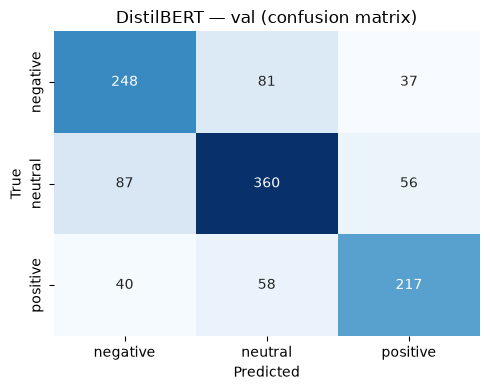


=== DistilBERT — test ===
Accuracy        : 0.6727
Precision (mac) : 0.6673
Recall    (mac) : 0.6657
F1        (mac) : 0.6660

Classification report:
              precision    recall  f1-score   support

    negative       0.65      0.60      0.63       733
     neutral       0.70      0.73      0.71      1006
    positive       0.65      0.67      0.66       629

    accuracy                           0.67      2368
   macro avg       0.67      0.67      0.67      2368
weighted avg       0.67      0.67      0.67      2368



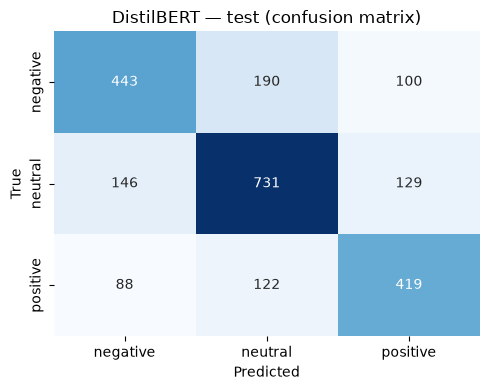

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.33s/it]



Saved → C:\Users\user\Documents\hpdp_project_2\models\distilbert_sentiment


In [9]:
# Predict labels for val + test
def predict_strings(dataset):
    out = trainer.predict(dataset)
    return [id2label[i] for i in np.argmax(out.predictions, axis=-1)]

bert_val_pred  = predict_strings(ds_val)
bert_val_m     = evaluate(df_val['sentiment_label'].values,  bert_val_pred,
                          'DistilBERT', 'val')

bert_test_pred = predict_strings(ds_test)
bert_test_m    = evaluate(df_test['sentiment_label'].values, bert_test_pred,
                          'DistilBERT', 'test')

# Save the fine-tuned model + tokenizer
BERT_OUT.mkdir(exist_ok=True)
trainer.save_model(str(BERT_OUT))
tokenizer.save_pretrained(str(BERT_OUT))
print(f'\nSaved → {BERT_OUT.resolve()}')

## 6. Compare — pick the best for the streaming pipeline

Selection criterion: highest **macro-F1 on test** (handles imbalance better than raw accuracy). Result written to `models/best_model_info.json` so Member 3's `spark_streaming.py` can read which model to load.

In [10]:
summary = pd.DataFrame([
    {'model': 'Logistic Regression', 'split': 'val',  **logreg_val_m},
    {'model': 'Logistic Regression', 'split': 'test', **logreg_test_m},
    {'model': 'DistilBERT',          'split': 'val',  **bert_val_m},
    {'model': 'DistilBERT',          'split': 'test', **bert_test_m},
])
print('=== Side-by-side ===')
print(summary.round(4).to_string(index=False))

# Pick winner on TEST macro-F1
test_only = summary[summary['split'] == 'test'].set_index('model')
winner    = test_only['f1_macro'].idxmax()

best_info = {
    'best_model':   winner,
    'path':         str((LOGREG_PATH if winner == 'Logistic Regression'
                         else BERT_OUT).resolve()),
    'kind':         'sklearn-pipeline' if winner == 'Logistic Regression'
                    else 'huggingface',
    'input_column': 'tokens' if winner == 'Logistic Regression' else 'clean_text',
    'labels':       LABELS,
    'test_metrics': test_only.loc[winner].to_dict(),
}
with open(MODELS_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_info, f, indent=2)

print(f'\n→ Best model: {winner}')
print(json.dumps(best_info, indent=2))

=== Side-by-side ===
              model split  accuracy  precision_macro  recall_macro  f1_macro
Logistic Regression   val    0.6419           0.6382        0.6427    0.6399
Logistic Regression  test    0.6136           0.6109        0.6119    0.6112
         DistilBERT   val    0.6968           0.6943        0.6941    0.6941
         DistilBERT  test    0.6727           0.6673        0.6657    0.6660

→ Best model: DistilBERT
{
  "best_model": "DistilBERT",
  "path": "C:\\Users\\user\\Documents\\hpdp_project_2\\models\\distilbert_sentiment",
  "kind": "huggingface",
  "input_column": "clean_text",
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "test_metrics": {
    "split": "test",
    "accuracy": 0.6727195945945946,
    "precision_macro": 0.6672750977149963,
    "recall_macro": 0.6657141682475595,
    "f1_macro": 0.6660377041874487
  }
}


## 7. Batch inference timing — baseline for Week 4 batch-vs-stream comparison

Measures **records per second** for both models on the full dataset. Member 3 will divide Spark Structured Streaming throughput against these numbers in Week 4.

In [11]:
def time_batch(name, predict_fn, n):
    t0 = time.time()
    predict_fn()
    elapsed = time.time() - t0
    rps = n / elapsed if elapsed > 0 else float('inf')
    print(f'{name:<22} : {n:>6,} rows in {elapsed:>6.2f}s   →  {rps:>8,.1f} rec/s')
    return {'rows': n, 'seconds': round(elapsed, 3), 'records_per_sec': round(rps, 1)}

n = len(df)
bench = {}

bench['logreg'] = time_batch(
    'Logistic Regression', lambda: logreg_pipe.predict(df['tokens']), n,
)

ds_all = to_hf(df).map(tokenize, batched=True)
bench['distilbert'] = time_batch(
    'DistilBERT', lambda: trainer.predict(ds_all), n,
)

with open(MODELS_DIR / 'batch_timing.json', 'w') as f:
    json.dump({'device': DEVICE, **bench}, f, indent=2)
print(f'\nSaved → {(MODELS_DIR / "batch_timing.json").resolve()}')

Logistic Regression    : 11,836 rows in   1.34s   →   8,853.4 rec/s


Map: 100%|██████████| 11836/11836 [00:00<00:00, 13262.53 examples/s]


DistilBERT             : 11,836 rows in  75.80s   →     156.1 rec/s

Saved → C:\Users\user\Documents\hpdp_project_2\models\batch_timing.json


## 8. Ensemble — soft-voting combination of LogReg + DistilBERT

Average the two models' predicted probabilities and take the argmax. The intuition: the two models make *different* errors — LogReg picks up strong Malay sentiment lexicon (`mantap`, `rosak`, `mahal`) very confidently, while DistilBERT handles context and code-switching better. Averaging their probabilities cancels some of each model's mistakes.

We try a few weightings to see which is best. Selection criterion stays the same: macro-F1 on test.

Test probas: logreg=(2368, 3), bert=(2368, 3)

=== Ensemble (0.5/0.5) — test ===
Accuracy        : 0.6921
Precision (mac) : 0.6879
Recall    (mac) : 0.6856
F1        (mac) : 0.6866

Classification report:
              precision    recall  f1-score   support

    negative       0.66      0.64      0.65       733
     neutral       0.72      0.74      0.73      1006
    positive       0.69      0.68      0.68       629

    accuracy                           0.69      2368
   macro avg       0.69      0.69      0.69      2368
weighted avg       0.69      0.69      0.69      2368



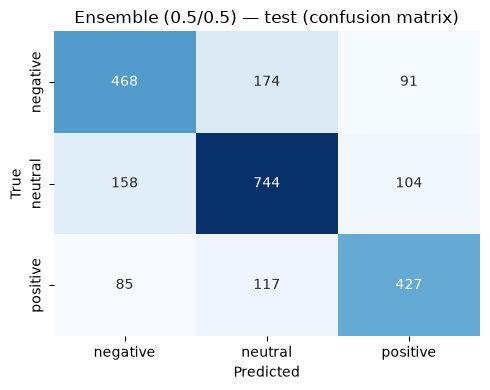


=== Ensemble (0.3 logreg/0.7 bert) — test ===
Accuracy        : 0.6858
Precision (mac) : 0.6813
Recall    (mac) : 0.6786
F1        (mac) : 0.6797

Classification report:
              precision    recall  f1-score   support

    negative       0.66      0.62      0.64       733
     neutral       0.71      0.74      0.72      1006
    positive       0.67      0.67      0.67       629

    accuracy                           0.69      2368
   macro avg       0.68      0.68      0.68      2368
weighted avg       0.68      0.69      0.69      2368



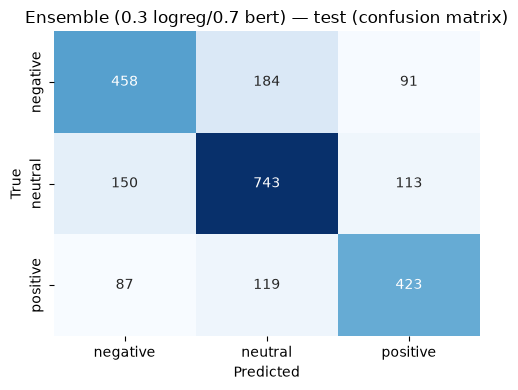


=== Ensemble (0.2 logreg/0.8 bert) — test ===
Accuracy        : 0.6795
Precision (mac) : 0.6743
Recall    (mac) : 0.6723
F1        (mac) : 0.6730

Classification report:
              precision    recall  f1-score   support

    negative       0.66      0.61      0.63       733
     neutral       0.71      0.73      0.72      1006
    positive       0.66      0.67      0.66       629

    accuracy                           0.68      2368
   macro avg       0.67      0.67      0.67      2368
weighted avg       0.68      0.68      0.68      2368



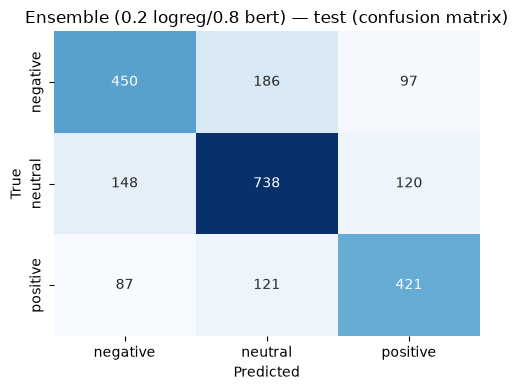


=== Test macro-F1 leaderboard ===
  0.6866  acc=0.6921  Ensemble (0.5/0.5)
  0.6797  acc=0.6858  Ensemble (0.3 logreg/0.7 bert)
  0.6730  acc=0.6795  Ensemble (0.2 logreg/0.8 bert)
  0.6660  acc=0.6727  DistilBERT
  0.6112  acc=0.6136  Logistic Regression

→ Overall winner: Ensemble (0.5/0.5)
{
  "best_model": "Ensemble (0.5/0.5)",
  "kind": "ensemble",
  "components": [
    {
      "kind": "sklearn-pipeline",
      "path": "C:\\Users\\user\\Documents\\hpdp_project_2\\models\\logreg_tfidf.joblib",
      "input_column": "tokens",
      "weight": 0.5
    },
    {
      "kind": "huggingface",
      "path": "C:\\Users\\user\\Documents\\hpdp_project_2\\models\\distilbert_sentiment",
      "input_column": "clean_text",
      "weight": 0.5
    }
  ],
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "test_metrics": {
    "accuracy": 0.6921452702702703,
    "precision_macro": 0.6878545348867617,
    "recall_macro": 0.6856299943035927,
    "f1_macro": 0.6866359026624004
  }
}


In [12]:
# ── Get aligned probabilities from each model on the test set ──────────────
logreg_classes = list(logreg_pipe.named_steps['clf'].classes_)
def logreg_proba(texts):
    p = logreg_pipe.predict_proba(texts)
    order = [logreg_classes.index(l) for l in LABELS]
    return p[:, order]

@torch.no_grad()
def bert_proba(texts, batch_size=32, max_len=MAX_LEN):
    model.eval()
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], truncation=True,
                        max_length=max_len, padding=True,
                        return_tensors='pt').to(model.device)
        logits = model(**enc).logits
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    p = np.vstack(out)
    bert_labels = [model.config.id2label[i] for i in range(p.shape[1])]
    order = [bert_labels.index(l) for l in LABELS]
    return p[:, order]

p_logreg = logreg_proba(df_test['tokens'].tolist())
p_bert   = bert_proba(df_test['clean_text'].tolist())
print(f'Test probas: logreg={p_logreg.shape}, bert={p_bert.shape}')

# ── Try three weightings, evaluate each ────────────────────────────────────
y_true_test = df_test['sentiment_label'].values
variants = {
    'Ensemble (0.5/0.5)':              0.5 * p_logreg + 0.5 * p_bert,
    'Ensemble (0.3 logreg/0.7 bert)':  0.3 * p_logreg + 0.7 * p_bert,
    'Ensemble (0.2 logreg/0.8 bert)':  0.2 * p_logreg + 0.8 * p_bert,
}
ensemble_results = {}
for name, probs in variants.items():
    preds = np.array(LABELS)[np.argmax(probs, axis=1)]
    ensemble_results[name] = evaluate(y_true_test, preds, name, 'test')

# ── Pick best ensemble + compare with singletons ──────────────────────────
all_test = {
    'Logistic Regression': logreg_test_m,
    'DistilBERT':          bert_test_m,
    **ensemble_results,
}
ranked = sorted(all_test.items(), key=lambda kv: kv[1]['f1_macro'], reverse=True)
print('\n=== Test macro-F1 leaderboard ===')
for name, m in ranked:
    print(f'  {m["f1_macro"]:.4f}  acc={m["accuracy"]:.4f}  {name}')

best_name, best_metrics = ranked[0]
print(f'\n→ Overall winner: {best_name}')

# ── Update best_model_info.json so Member 3 knows what to load ────────────
if best_name.startswith('Ensemble'):
    weights = {'Ensemble (0.5/0.5)': [0.5, 0.5],
               'Ensemble (0.3 logreg/0.7 bert)': [0.3, 0.7],
               'Ensemble (0.2 logreg/0.8 bert)': [0.2, 0.8]}[best_name]
    best_info = {
        'best_model':   best_name,
        'kind':         'ensemble',
        'components': [
            {'kind': 'sklearn-pipeline', 'path': str(LOGREG_PATH.resolve()),
             'input_column': 'tokens',     'weight': weights[0]},
            {'kind': 'huggingface',      'path': str(BERT_OUT.resolve()),
             'input_column': 'clean_text', 'weight': weights[1]},
        ],
        'labels':       LABELS,
        'test_metrics': best_metrics,
    }
else:
    best_info = {
        'best_model':   best_name,
        'kind':         'sklearn-pipeline' if best_name == 'Logistic Regression' else 'huggingface',
        'path':         str((LOGREG_PATH if best_name == 'Logistic Regression' else BERT_OUT).resolve()),
        'input_column': 'tokens' if best_name == 'Logistic Regression' else 'clean_text',
        'labels':       LABELS,
        'test_metrics': best_metrics,
    }

with open(MODELS_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_info, f, indent=2)
print(json.dumps(best_info, indent=2))